In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st


 Temporal dynamics: Download the 2017 dataset on the data.gouv website and concatenate
it with 2018. Are there seasonal trends? Do accidents spike during specific holidays or specific
days of the week?

In [ ]:
df18_car = pd.read_csv("acc-data/ACC-caracteristiques-2018.csv")
df18_lieux = pd.read_csv("acc-data/ACC-lieux-2018.csv")
df18_usag = pd.read_csv("acc-data/ACC-usagers-2018.csv")
df18_vehic = pd.read_csv("acc-data/ACC-vehicules-2018.csv")
#Individual df for 2018 

C:\Users\salva\AppData\Local\Temp\ipykernel_14304\2945563687.py:2: DtypeWarning: Columns (0: voie) have mixed types. Specify dtype option on import or set low_memory=False.
  df18_lieux = pd.read_csv("acc-data/ACC-lieux-2018.csv")


In [ ]:
df17_car = pd.read_csv("acc2017/caracteristiques-2017.csv",encoding='latin-1')
df17_lieux = pd.read_csv("acc2017/lieux-2017.csv",encoding='latin-1')
df17_usag = pd.read_csv("acc2017/usagers-2017.csv",encoding='latin-1')
df17_vehic = pd.read_csv("acc2017/vehicules-2017.csv",encoding='latin-1')
#individual df for 2017

C:\Users\salva\AppData\Local\Temp\ipykernel_14304\166248906.py:2: DtypeWarning: Columns (0: voie) have mixed types. Specify dtype option on import or set low_memory=False.
  df17_lieux = pd.read_csv("acc2017/lieux-2017.csv",encoding='latin-1')


In [ ]:
df17_full = df17_car.merge(df17_lieux, on='Num_Acc', how='left') \
                    .merge(df17_vehic, on='Num_Acc', how='left') \
                    .merge(df17_usag, on=['Num_Acc', 'num_veh'], how='left')

df17_full
#Full 2017 Table


,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais
0,201700000001,17,1,11,1820,5,2,1,1.0,1.0,...,1.0,1.0,3.0,1.0,9.0,13.0,0.0,0.0,0.0,1968.0
1,201700000001,17,1,11,1820,5,2,1,1.0,1.0,...,2.0,2.0,3.0,2.0,9.0,11.0,0.0,0.0,0.0,1973.0
2,201700000001,17,1,11,1820,5,2,1,1.0,1.0,...,1.0,1.0,3.0,1.0,1.0,13.0,0.0,0.0,0.0,1967.0
3,201700000002,17,2,13,1630,1,2,3,1.0,3.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1953.0
4,201700000002,17,2,13,1630,1,2,3,1.0,3.0,...,1.0,1.0,3.0,1.0,5.0,22.0,0.0,0.0,0.0,1960.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137903,201700060699,17,11,26,1745,2,2,1,1.0,3.0,...,1.0,1.0,1.0,2.0,9.0,11.0,0.0,0.0,0.0,1974.0
137904,201700060700,17,11,28,1405,1,2,1,1.0,3.0,...,1.0,1.0,1.0,2.0,9.0,11.0,0.0,0.0,0.0,1987.0
137905,201700060700,17,11,28,1405,1,2,1,1.0,3.0,...,1.0,1.0,4.0,1.0,9.0,21.0,0.0,0.0,0.0,1991.0
137906,201700060700,17,11,28,1405,1,2,1,1.0,3.0,...,2.0,2.0,4.0,2.0,9.0,21.0,0.0,0.0,0.0,1990.0


In [ ]:
df18_full = df18_car.merge(df18_lieux, on='Num_Acc', how='left') \
                    .merge(df18_vehic, on='Num_Acc', how='left') \
                    .merge(df18_usag, on=['Num_Acc', 'num_veh'], how='left')

df18_full
#Full 2018 table

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais
0,201800000001,18,1,24,1505,1,1,4,1.0,1.0,...,1.0,1.0,3.0,1.0,0.0,11.0,0.0,0.0,0.0,1928.0
1,201800000001,18,1,24,1505,1,1,4,1.0,1.0,...,1.0,1.0,1.0,1.0,5.0,11.0,0.0,0.0,0.0,1960.0
2,201800000002,18,2,12,1015,1,2,7,7.0,7.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1947.0
3,201800000002,18,2,12,1015,1,2,7,7.0,7.0,...,NaN,3.0,4.0,1.0,0.0,2.0,2.0,3.0,1.0,1959.0
4,201800000003,18,3,4,1135,1,2,3,1.0,7.0,...,1.0,1.0,3.0,1.0,5.0,21.0,0.0,0.0,0.0,1987.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131999,201800057781,18,12,22,2150,5,2,1,1.0,6.0,...,NaN,3.0,4.0,1.0,9.0,3.0,4.0,3.0,1.0,1975.0
132000,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1.0,1.0,4.0,2.0,9.0,11.0,NaN,NaN,NaN,1993.0
132001,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1.0,1.0,4.0,1.0,9.0,21.0,NaN,NaN,NaN,1974.0
132002,201800057783,18,12,28,1425,1,2,1,1.0,1.0,...,1.0,1.0,4.0,1.0,9.0,11.0,NaN,NaN,NaN,1973.0


In [ ]:
diff = len(df18_car['Num_Acc'])-len(df17_car['Num_Acc'])
diff
#Difference between amount of acc 2018 --> 2017

-2918

In [ ]:

df_total = pd.concat([df17_full, df18_full], ignore_index=True)

print(f"total rows: {len(df_total)}")
print(df_total['an'].value_counts())

#Concatenated df (2017-2018)

total rows: 269912
an
17    137908
18    132004
Name: count, dtype: int64


In [ ]:
# Filter and show columns with at least one Nan
null = df_total.isnull().sum()
print(null[null > 0])

atm            35
col            21
adr          3276
gps         10494
lat         22512
long        22512
voie        68134
v1         268674
v2         257457
circ         1801
nbv          2201
pr         108476
pr1        109586
vosp         2605
prof         2060
plan         2978
lartpc     107706
larrout    106441
surf         2113
infra        9755
situ         9377
env1         9858
senc          267
obs           314
obsm          210
choc          210
manv          209
place       26484
catu         3722
grav         3722
sexe         3722
trajet       3847
secu        16801
locp        58419
actp        58411
etatp       58434
an_nais      3789
dtype: int64


In [1]:
df_lyon = df_total[df_total['dep'] ==690].reset_index(drop=True)
df_lyon
#Get only the accidents from Lyon

NameError: name 'df_total' is not defined

In [ ]:
df_paris = df_total[df_total['dep'] ==750].reset_index(drop=True)
df_paris
#Get only teh accidents in paris

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais
0,201700046379,17,1,10,2350,5,1,1,1.0,7.0,...,1.0,1.0,4.0,1.0,5.0,11.0,0.0,0.0,0.0,1993.0
1,201700046379,17,1,10,2350,5,1,1,1.0,7.0,...,2.0,2.0,4.0,1.0,5.0,11.0,0.0,0.0,0.0,1997.0
2,201700046379,17,1,10,2350,5,1,1,1.0,7.0,...,3.0,2.0,4.0,1.0,5.0,11.0,0.0,0.0,0.0,1996.0
3,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1966.0
4,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1978.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24289,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,1.0,1.0,1.0,5.0,11.0,NaN,NaN,NaN,1988.0
24290,201800055765,18,12,29,1215,1,2,1,1.0,3.0,...,1.0,1.0,4.0,1.0,1.0,21.0,NaN,NaN,NaN,1989.0
24291,201800055765,18,12,29,1215,1,2,1,1.0,3.0,...,1.0,1.0,1.0,1.0,5.0,11.0,NaN,NaN,NaN,1998.0
24292,201800055766,18,12,31,1740,5,2,1,1.0,2.0,...,1.0,1.0,1.0,1.0,5.0,11.0,NaN,NaN,NaN,1992.0


In [ ]:
df_lyongender = df_lyon[(df_lyon['place']==1) & (df_lyon['catv']==7)].reset_index(drop=True)

In [ ]:
df_lyongender = df_lyongender.dropna(subset=('sexe'))

In [ ]:
df_lyongender['sexe'].value_counts(dropna=False)
#The count of man and women in lyon

sexe
1.0    3320
2.0    1723
Name: count, dtype: int64

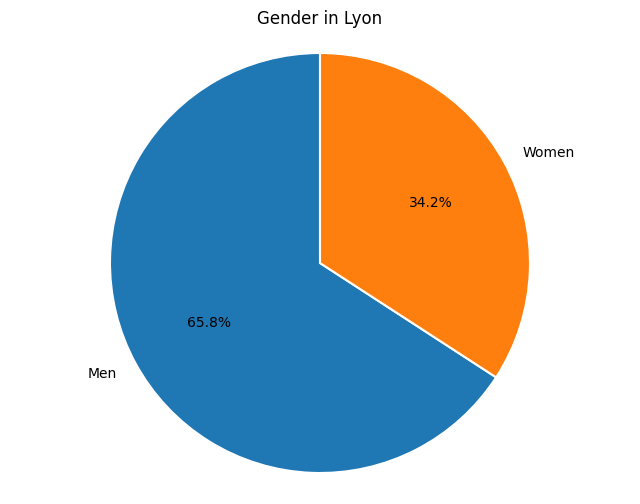

In [ ]:
gender_l = df_lyongender['sexe'].map({1.0:'Men',2.0:'Women'}).value_counts()
plt.figure(figsize=(8,6))
plt.pie(gender_l,labels=gender_l.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Gender in Lyon')
plt.axis('equal')
plt.show()

In [ ]:
#Accidents of cars based on the driver 
df_parisgender = df_paris[(df_paris['place']==1) & (df_paris['catv']==7)].reset_index(drop=True)
df_parisgender

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais
0,201700046379,17,1,10,2350,5,1,1,1.0,7.0,...,1.0,1.0,4.0,1.0,5.0,11.0,0.0,0.0,0.0,1993.0
1,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1966.0
2,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1978.0
3,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,1.0,1.0,1.0,0.0,11.0,0.0,0.0,0.0,1965.0
4,201700046428,17,2,6,620,5,1,1,2.0,2.0,...,1.0,1.0,1.0,1.0,5.0,11.0,0.0,0.0,0.0,1952.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8509,201800055763,18,12,25,1945,5,2,1,1.0,4.0,...,1.0,1.0,1.0,2.0,5.0,11.0,NaN,NaN,NaN,1971.0
8510,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,1.0,4.0,1.0,0.0,11.0,NaN,NaN,NaN,1996.0
8511,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,1.0,1.0,1.0,5.0,11.0,NaN,NaN,NaN,1988.0
8512,201800055765,18,12,29,1215,1,2,1,1.0,3.0,...,1.0,1.0,1.0,1.0,5.0,11.0,NaN,NaN,NaN,1998.0


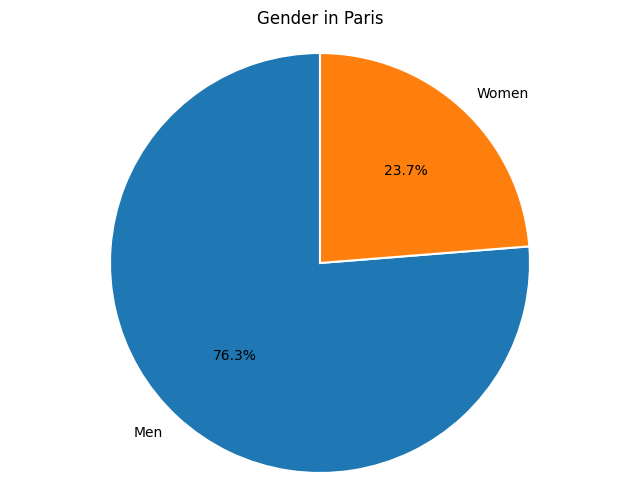

In [ ]:
gender_p = df_parisgender['sexe'].map({1.0:'Men',2.0:'Women'}).value_counts()
plt.figure(figsize=(8,6))
plt.pie(gender_p,labels=gender_p.index,autopct='%1.1f%%',startangle=90,wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Gender in Paris')
plt.axis('equal')
plt.show()

In [ ]:
df_accparis = df_parisgender[df_parisgender['secu'].isin([11, 12])]
df_accparis['gender'] = df_parisgender['sexe'].map({1.0:'Men',2.0:'Women'})
df_accparis['seatbelt'] = df_accparis['secu'].map({11: 'with seatbelt', 12: 'without seatbelt'})
df_accparis['severity'] = df_accparis['grav'].map({
    1: 'Minor / Uninjured', 
    4: 'Minor / Uninjured',
    2: 'Severe / Fatal', 
    3: 'Severe / Fatal'
})
df_accparis = df_accparis.dropna(subset=('seatbelt','severity','sexe'))
#We make gruops and rename certain into new categorical values

In [ ]:
df_accparis

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,sexe,trajet,secu,locp,actp,etatp,an_nais,gender,seatbelt,severity
0,201700046379,17,1,10,2350,5,1,1,1.0,7.0,...,1.0,5.0,11.0,0.0,0.0,0.0,1993.0,Men,with seatbelt,Minor / Uninjured
1,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,0.0,11.0,0.0,0.0,0.0,1966.0,Men,with seatbelt,Minor / Uninjured
2,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,0.0,11.0,0.0,0.0,0.0,1978.0,Men,with seatbelt,Minor / Uninjured
3,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,0.0,11.0,0.0,0.0,0.0,1965.0,Men,with seatbelt,Minor / Uninjured
4,201700046428,17,2,6,620,5,1,1,2.0,2.0,...,1.0,5.0,11.0,0.0,0.0,0.0,1952.0,Men,with seatbelt,Minor / Uninjured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8509,201800055763,18,12,25,1945,5,2,1,1.0,4.0,...,2.0,5.0,11.0,NaN,NaN,NaN,1971.0,Women,with seatbelt,Minor / Uninjured
8510,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,0.0,11.0,NaN,NaN,NaN,1996.0,Men,with seatbelt,Minor / Uninjured
8511,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,5.0,11.0,NaN,NaN,NaN,1988.0,Men,with seatbelt,Minor / Uninjured
8512,201800055765,18,12,29,1215,1,2,1,1.0,3.0,...,1.0,5.0,11.0,NaN,NaN,NaN,1998.0,Men,with seatbelt,Minor / Uninjured


In [ ]:
#Accidents with and without seatbelt
accp_sbelt = df_accparis[(df_accparis['secu'] ==11)]
accp_wsbelt = df_accparis[df_accparis['secu'] ==12]

#Minor and uninjured accidents with seatbelt
accp_sbmun = accp_sbelt[(accp_sbelt['grav']==1)|(accp_sbelt['grav']==4)]
accp_sbmin = accp_sbelt[(accp_sbelt['grav']==2)|(accp_sbelt['grav']==3)]

#Major and deathly accidents without seatbelt
accp_wsbmun = accp_wsbelt[(accp_wsbelt['grav']==1)|(accp_wsbelt['grav']==4)]
accp_wsbmin = accp_wsbelt[(accp_wsbelt['grav']==2)|(accp_wsbelt['grav']==3)]

In [ ]:
accp_sbmun

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,sexe,trajet,secu,locp,actp,etatp,an_nais,gender,seatbelt,severity
0,201700046379,17,1,10,2350,5,1,1,1.0,7.0,...,1.0,5.0,11.0,0.0,0.0,0.0,1993.0,Men,with seatbelt,Minor / Uninjured
1,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,0.0,11.0,0.0,0.0,0.0,1966.0,Men,with seatbelt,Minor / Uninjured
2,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,0.0,11.0,0.0,0.0,0.0,1978.0,Men,with seatbelt,Minor / Uninjured
3,201700046413,17,1,31,1600,1,1,1,2.0,4.0,...,1.0,0.0,11.0,0.0,0.0,0.0,1965.0,Men,with seatbelt,Minor / Uninjured
4,201700046428,17,2,6,620,5,1,1,2.0,2.0,...,1.0,5.0,11.0,0.0,0.0,0.0,1952.0,Men,with seatbelt,Minor / Uninjured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8509,201800055763,18,12,25,1945,5,2,1,1.0,4.0,...,2.0,5.0,11.0,NaN,NaN,NaN,1971.0,Women,with seatbelt,Minor / Uninjured
8510,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,0.0,11.0,NaN,NaN,NaN,1996.0,Men,with seatbelt,Minor / Uninjured
8511,201800055764,18,12,28,250,5,2,1,1.0,2.0,...,1.0,5.0,11.0,NaN,NaN,NaN,1988.0,Men,with seatbelt,Minor / Uninjured
8512,201800055765,18,12,29,1215,1,2,1,1.0,3.0,...,1.0,5.0,11.0,NaN,NaN,NaN,1998.0,Men,with seatbelt,Minor / Uninjured


In [ ]:
#Percentage of seatbelt and without seatbelt
seatbelt = (len(accp_sbelt)/len(df_accparis))*100
no_seatbelt = (len(accp_wsbelt)/len(df_accparis))*100

#Percentage minor and major accidents with seatbelt
minor_seatbelt = (len(accp_sbmun)/len(accp_sbelt))*100
major_seatbelt = (len(accp_sbmin)/len(accp_sbelt))*100

#Percentage minor and major accidents without seatbelts
minor_nseatbelt = (len(accp_wsbmun)/len(accp_wsbelt))*100
major_nseatbelt = (len(accp_wsbmin)/len(accp_wsbelt))*100

In [ ]:
print(f'After a full analysis, we noticed that from the total of accidents in paris \nthere is a {seatbelt:,.2f}% of accidents where the drivers were using seatbelt,\n meanwhile there is a {no_seatbelt:,.2f}%  of accidents without seatbelt ')

After a full analysis, we noticed that from the total of accidents in paris 
there is a 99.25% of accidents where the drivers were using seatbelt,
 meanwhile there is a 0.75%  of accidents without seatbelt 


In [ ]:
print(f"However if we deepen, we also notice that from the total accidents where the drivers were using the seatbelt, there is a {minor_seatbelt:,.2f}% which is minor or uninjured, an a {major_seatbelt:,.2f}% which is major or deathly")

However if we deepen, we also notice that from the total accidents where the drivers were using the seatbelt, there is a 99.38% which is minor or uninjured, an a 0.62% which is major or deathly


In [ ]:
print(f"Meanwhile, from the accidents where the drivers was not using seatbelt, we have {minor_nseatbelt:,.2f}% of minor or uninjured, and {major_nseatbelt:,.2f}% of major or deathly")

Meanwhile, from the accidents where the drivers was not using seatbelt, we have 98.21% of minor or uninjured, and 1.79% of major or deathly


Which is a x2.8 more major or deathly accidents than the ones


 where the driver uses seatbelt. 

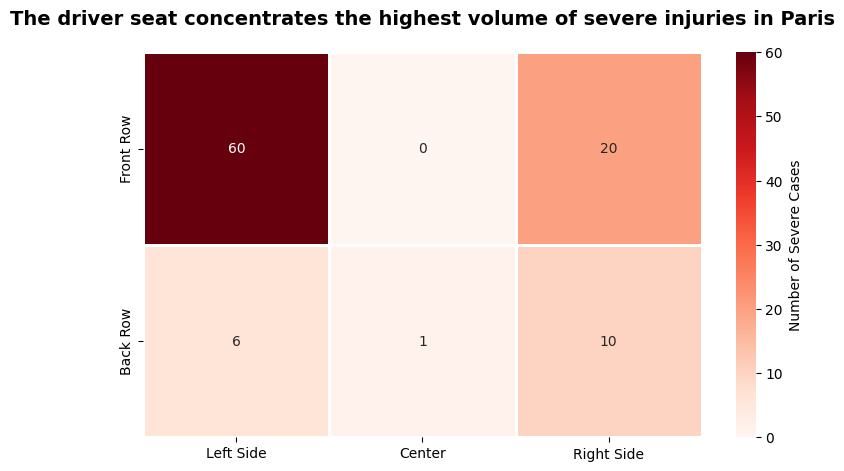

In [ ]:
df_severe_carsp = df_paris[(df_paris['catv'] == 7) & (df_paris['grav'].isin([2, 3]))]

seat_countsp = df_severe_carsp['place'].value_counts()

def get_seat_count(seat):
    return seat_countsp.get(seat, 0)

matrix_paris = np.array([
    [get_seat_count(1), 0, get_seat_count(2)], 
    [get_seat_count(4), get_seat_count(5), get_seat_count(3)]
])

df_heatmap_paris = pd.DataFrame(
    matrix_paris, 
    index=['Front Row', 'Back Row'], 
    columns=['Left Side', 'Center', 'Right Side']
)

plt.figure(figsize=(9, 5))

heatmap_plot = sns.heatmap(
    df_heatmap_paris, 
    annot=True, 
    fmt=".0f", 
    cmap="Reds", 
    linewidths=2, 
    linecolor='white', 
    cbar_kws={'label': 'Number of Severe Cases'}
)

plt.title('The driver seat concentrates the highest volume of severe injuries in Paris', fontsize=14, fontweight='bold', pad=20)

plt.show()

*Heatmaps of Lyon and Paris, to check who recieves the worst damage from the accidents in a car.*

In [ ]:
df_severe_carsp['place'].isna().sum()


np.int64(196)

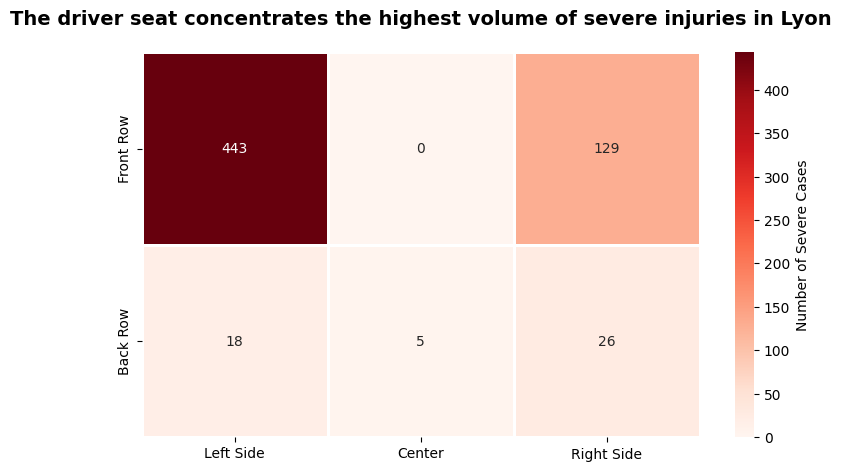

In [ ]:
df_severe_carsl = df_lyon[(df_lyon['catv'] == 7) & (df_lyon['grav'].isin([2, 3]))]

seat_countsl = df_severe_carsl['place'].value_counts()

def get_seat_count(seat):
    return seat_countsl.get(seat, 0)

matrix_lyon = np.array([
    [get_seat_count(1), 0, get_seat_count(2)], 
    [get_seat_count(4), get_seat_count(5), get_seat_count(3)]
])

df_heatmap_lyon = pd.DataFrame(
    matrix_lyon , 
    index=['Front Row', 'Back Row'], 
    columns=['Left Side', 'Center', 'Right Side']
)

plt.figure(figsize=(9, 5))

heatmap_plot = sns.heatmap(
    df_heatmap_lyon, 
    annot=True, 
    fmt=".0f", 
    cmap="Reds", 
    linewidths=2, 
    linecolor='white', 
    cbar_kws={'label': 'Number of Severe Cases'}
)

plt.title('The driver seat concentrates the highest volume of severe injuries in Lyon', fontsize=14, fontweight='bold',pad=20)

plt.show()

In [ ]:
df_severe_carsl['place'].isna().sum()

np.int64(298)